In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [13]:
def load_and_preprocess(filepath):
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}. Please upload 'data.csv'.")
        return None, None, None

    if 'id' in df.columns:
        df = df.drop('id', axis=1)

    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    target_col = [c for c in df.columns if 'diagnosis' in c.lower()][0]
    df[target_col] = df[target_col].map({'M': 1, 'B': 0})

    # Split Features (X) and Target (y)
    X = df.drop(target_col, axis=1).values
    y = df[target_col].values

    # Normalize Features (Min-Max Scaling)
    min_val = X.min(axis=0)
    max_val = X.max(axis=0)
    range_val = max_val - min_val

    # Avoid division by zero for constant columns
    range_val[range_val == 0] = 1
    X_normalized = (X - min_val) / range_val

    return X_normalized, y, df.drop(target_col, axis=1).columns

In [14]:
def custom_train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    test_samples = int(len(X) * test_size)

    test_indices = indices[:test_samples]
    train_indices = indices[test_samples:]

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


In [15]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

def minkowski_distance(x1, x2, p=3):
    return np.sum(np.abs(x1 - x2)**p)**(1/p)

def cosine_distance(x1, x2):
    dot_product = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    if norm_x1 == 0 or norm_x2 == 0:
        return 1.0
    return 1 - (dot_product / (norm_x1 * norm_x2))

def hamming_distance(x1, x2):
    return np.sum(x1 != x2)


In [16]:
class KNN:
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        predictions = []

        # Pre-select distance function to avoid if-check inside loop
        if self.distance_metric == 'euclidean':
            dist_func = euclidean_distance
        elif self.distance_metric == 'manhattan':
            dist_func = manhattan_distance
        elif self.distance_metric == 'minkowski':
            dist_func = minkowski_distance
        elif self.distance_metric == 'cosine':
            dist_func = cosine_distance
        elif self.distance_metric == 'hamming':
            dist_func = hamming_distance
        else:
            raise ValueError("Unknown distance metric")

        for x in X_test:
            distances = [dist_func(x, x_train) for x_train in self.X_train]
            distances = np.array(distances)

            # Find indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]

            # Get labels of neighbors
            k_nearest_labels = self.y_train[k_indices]

            # Majority Vote
            most_common = Counter(k_nearest_labels).most_common(1)
            predictions.append(most_common[0][0])

        return np.array(predictions)

In [17]:
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    return accuracy, precision, recall, [[tn, fp], [fn, tp]]

In [18]:
def run_experiments(X_train, y_train, X_test, y_test, k_values, metrics_list):
    results = {}
    best_acc = -1
    best_info = {}

    print("\nStarting Experiments...")

    for metric in metrics_list:
        acc_list = []
        for k in k_values:
            # Initialize and Train
            model = KNN(k=k, distance_metric=metric)
            model.fit(X_train, y_train)

            # Predict
            predictions = model.predict(X_test)

            # Evaluate
            acc, prec, rec, cm = calculate_metrics(y_test, predictions)
            acc_list.append(acc)

            # Track Best Model
            if acc > best_acc:
                best_acc = acc
                best_info = {
                    'config': {'k': k, 'metric': metric},
                    'metrics': {'acc': acc, 'prec': prec, 'rec': rec, 'cm': cm}
                }

        results[metric] = acc_list
        print(f"Finished experiments for {metric} distance.")

    return results, best_info

In [19]:
def print_results(best_info):
    """Prints the final performance report."""
    config = best_info['config']
    metrics = best_info['metrics']

    print("\n" + "="*30)
    print(f"BEST CONFIGURATION: K={config['k']}, Metric={config['metric']}")
    print("="*30)
    print(f"Testing Accuracy: {metrics['acc']:.4f}")
    print(f"Precision:        {metrics['prec']:.4f}")
    print(f"Recall:           {metrics['rec']:.4f}")
    print(f"Confusion Matrix:\n{np.array(metrics['cm'])}")


In [20]:
def plot_accuracy(results, k_values):
    """Plots the K vs Accuracy graph."""
    plt.figure(figsize=(10, 6))
    for metric, accs in results.items():
        plt.plot(k_values, accs, marker='o', label=metric)

    plt.title('Impact of K and Distance Metric on Accuracy')
    plt.xlabel('K (Number of Neighbors)')
    plt.ylabel('Testing Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


In [21]:
def plot_decision_boundary(X_train, y_train, best_config, feature_names):
    print("\nGenerating Decision Boundary Plot (using first 2 features)...")

    feature_idx_1, feature_idx_2 = 0, 1
    X_vis = X_train[:, [feature_idx_1, feature_idx_2]]

    h = 0.02
    x_min, x_max = X_vis[:, 0].min() - 0.1, X_vis[:, 0].max() + 0.1
    y_min, y_max = X_vis[:, 1].min() - 0.1, X_vis[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Re-train KNN on just these 2 features for visualization
    knn_vis = KNN(k=best_config['k'], distance_metric=best_config['metric'])
    knn_vis.fit(X_vis, y_train)

    # Predict on mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = knn_vis.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm, s=20)
    plt.xlabel(feature_names[feature_idx_1])
    plt.ylabel(feature_names[feature_idx_2])
    plt.title(f"Decision Boundary (K={best_config['k']}, {best_config['metric']})")
    plt.show()


In [22]:
def task1():
    file_path = '/content/data.csv'

    X, y, feature_names = load_and_preprocess(file_path)

    if X is not None:
        X_train, X_test, y_train, y_test = custom_train_test_split(X, y, test_size=0.2)
        print(f"Data Loaded. Training samples: {len(X_train)}, Test samples: {len(X_test)}")

        # Hyperparameters
        k_values = [3, 4, 9, 20, 47]
        metrics_list = ['euclidean', 'manhattan', 'minkowski', 'cosine', 'hamming']

        results, best_info = run_experiments(X_train, y_train, X_test, y_test, k_values, metrics_list)

        print_results(best_info)

        plot_accuracy(results, k_values)

        plot_decision_boundary(X_train, y_train, best_info['config'], feature_names)

    else:
        print("Code execution stopped due to missing data.")

Data Loaded. Training samples: 456, Test samples: 113

Starting Experiments...
Finished experiments for euclidean distance.
Finished experiments for manhattan distance.
Finished experiments for minkowski distance.
Finished experiments for cosine distance.
Finished experiments for hamming distance.

BEST CONFIGURATION: K=9, Metric=manhattan
Testing Accuracy: 0.9735
Precision:        0.9756
Recall:           0.9524
Confusion Matrix:
[[70  1]
 [ 2 40]]


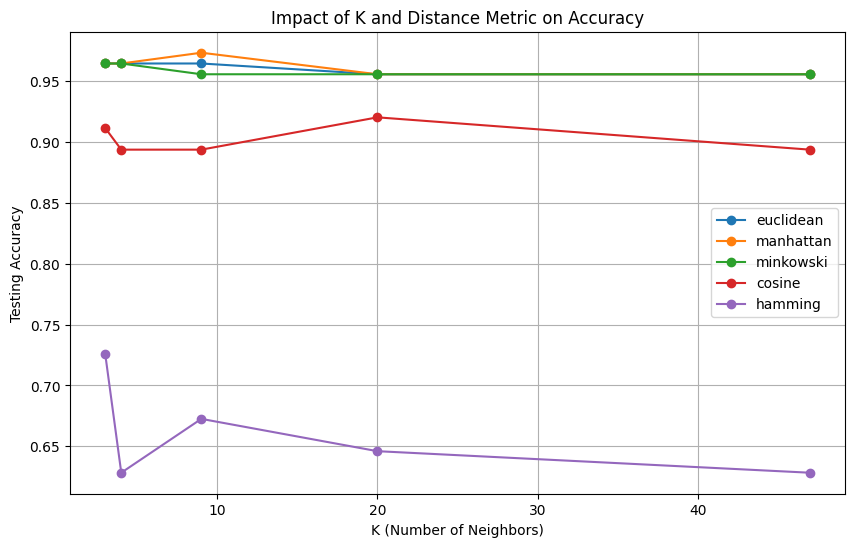


Generating Decision Boundary Plot (using first 2 features)...


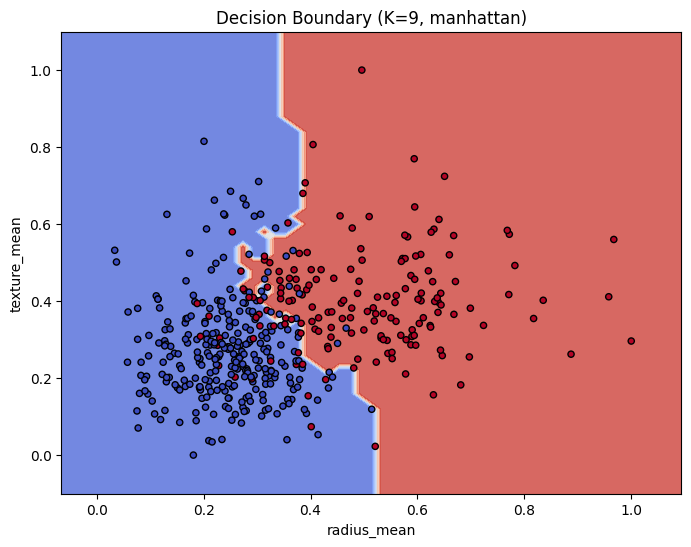

In [23]:
if __name__ == "__main__":
    task1()